# 🍽️ NYC Restaurant Intelligence: End-to-End Data Pipeline

**Project Goal:** Analyzing the relationship between restaurant pricing, cuisine types, and health inspection performance in New York City using Web Scraping, REST APIs, and Spatial Data.

## Step 1: Environment Setup & Initialization
Importing necessary libraries and configuring a dynamic directory structure (`pathlib`) to ensure reproducibility across different environments. Securely loading API keys via `.env`.

In [30]:
import pandas as pd
import sqlite3
import requests
import os
from dotenv import load_dotenv
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

load_dotenv()

BASE_DIR = Path.cwd().parent
RAW_DIR = BASE_DIR / 'data' / 'raw'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
SPATIAL_DIR = BASE_DIR / 'data' / 'spatial'

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
SPATIAL_DIR.mkdir(parents=True, exist_ok=True)


## Step 2: Data Extraction (The 'E' in ETL)

### 2.1 Web Scraping: Health Inspections Data
Extracting the latest health inspection results from a public HTML table and backing up the raw data to the `data/raw/` directory.

In [31]:
url_inspections = "https://dlai-lc-dag.s3.us-east-2.amazonaws.com/restaurant_inspections.html"
inspections_df = pd.read_html(url_inspections)[0]

inspections_df.to_csv(RAW_DIR / 'raw_inspections.csv', index=False)

inspections_df.shape, inspections_df.head(2)

((50102, 26),
       CAMIS     DBA      BORO BUILDING           STREET  ZIPCODE       PHONE  \
 0  50060054  SBARRO  Brooklyn     2509  FLATBUSH AVENUE  11234.0  7182583869   
 1  41305916  DUNKIN    Queens    13504   JAMAICA AVENUE  11418.0  7182629567   
 
   CUISINE DESCRIPTION INSPECTION DATE  \
 0               Pizza      07/01/2024   
 1              Donuts      07/01/2024   
 
                                             ACTION  ... RECORD DATE  \
 0  Violations were cited in the following area(s).  ...  02/20/2025   
 1  Violations were cited in the following area(s).  ...  02/20/2025   
 
                          INSPECTION TYPE   Latitude  Longitude  \
 0  Cycle Inspection / Initial Inspection  40.609174 -73.921785   
 1  Cycle Inspection / Initial Inspection  40.702394 -73.817640   
 
   Community Board Council District Census Tract        BIN           BBL   NTA  
 0           318.0             46.0      69800.0  3326830.0  3.084700e+09  BK45  
 1           409.0          

### 2.2 REST API Integration: Restaurant Ratings
Paginating through a business intelligence API to securely extract 35,000+ restaurant ratings. Utilizing `requests.Session()` for connection pooling and optimized network performance.

In [32]:
API_KEY = os.getenv("RESTAURANTS_API_KEY")
API_URL = "https://2eraiuh.dlai.link/api/business_info"

with requests.Session() as session:
    session.params = {"api_key": API_KEY, "limit": 1000}
    
    dfs = []
    for offset in range(0, 35000, 1000):
        resp = session.get(API_URL, params={"offset": offset})
        resp.raise_for_status() 
        
        data = resp.json().get("data", [])
        dfs.append(pd.DataFrame(data))

ratings_df = pd.concat(dfs, ignore_index=True)
ratings_df.drop_duplicates(inplace=True)

ratings_df.to_csv(RAW_DIR / 'raw_ratings.csv', index=False)

ratings_df.shape, ratings_df.head(2)

((35000, 7),
                                              address  \
 0  114 E Burnside Ave, Bronx, NY 10453, United St...   
 1  238 Thompson St, New York, NY 10012, United St...   
 
                          name                     place_id price_level  \
 0   San Lucas #2 Mexican Food  ChIJB9BYbbj1wokRJ24ZgjuZplM          $$   
 1  The Catholic Center at NYU  ChIJPWJOEJFZwokRX9iE7AMRQ0A        None   
 
    rating  total_reviews                                              types  
 0     3.6           47.0  restaurant, point_of_interest, food, establish...  
 1     4.7           14.0  church, place_of_worship, point_of_interest, e...  )

## Step 3: Data Transformation & Cleansing (The 'T' in ETL)

### 3.1 Cleaning Inspections Data
Standardizing restaurant names, converting dates to datetime objects, and normalizing street names for better SQL compatibility.

In [33]:
inspections_clean = inspections_df.copy()

# A. Standardize Restaurant Names
special_char_pattern = r"[^A-Z0-9 ]"
inspections_clean["DBA"] = inspections_clean["DBA"].str.replace(special_char_pattern, "", regex=True)
inspections_clean["DBA"] = inspections_clean["DBA"].str.replace(r"\s+", " ", regex=True).str.strip()

# B. Convert Dates to Datetime objects
date_columns = ["INSPECTION DATE", "GRADE DATE", "RECORD DATE"]
for col in date_columns:
    inspections_clean[col] = pd.to_datetime(inspections_clean[col], errors='coerce')

# C. Clean Inspection Type
inspections_clean["INSPECTION TYPE"] = inspections_clean["INSPECTION TYPE"].str.split("/").str[1].str.strip()

# D. Standardize Street Names
street_mapping = {
    "AVENUE": "AVE", "STREET": "ST", "ROAD": "RD", "BOULEVARD": "BLVD",
    "DRIVE": "DR", "LANE": "LN", "COURT": "CT", "PLACE": "PL"
}
inspections_clean["STREET"] = inspections_clean["STREET"].replace(street_mapping, regex=True)

# E. Fix Column Names
inspections_clean.columns = inspections_clean.columns.str.replace(" ", "_")

inspections_clean[['CAMIS', 'DBA', 'STREET', 'INSPECTION_DATE', 'INSPECTION_TYPE']].head(3)

,CAMIS,DBA,STREET,INSPECTION_DATE,INSPECTION_TYPE
0,50060054,SBARRO,FLATBUSH AVE,2024-07-01,Initial Inspection
1,41305916,DUNKIN,JAMAICA AVE,2024-07-01,Initial Inspection
2,41665625,FORGTMENOT,DIVISION ST,2024-07-01,Initial Inspection


### 3.2 Cleaning Ratings Data
Extracting spatial features (ZIP codes) using Regular Expressions (Regex), converting price scales to numeric values, and filtering for NYC regions only.

In [34]:
ratings_clean = ratings_df.copy()

# A. Standardize Restaurant Names
ratings_clean["name"] = ratings_clean["name"].str.upper()
ratings_clean["name"] = ratings_clean["name"].str.replace(special_char_pattern, "", regex=True)
ratings_clean["name"] = ratings_clean["name"].str.replace(r"\s+", " ", regex=True).str.strip()

# B. Convert Price Levels to Numeric scale
price_mapping = {
    "$$$$$": 5, "$$$$": 4, "$$$": 3, 
    "$$": 2, "$": 1, " - No ratings yet": 0
}
ratings_clean["price_level"] = ratings_clean["price_level"].replace(price_mapping)

# C. Extract ZIP Code from Address using Regex
ratings_clean["zip_code"] = ratings_clean["address"].str.extract(r"(\d{5})")

# D. Convert Data Types
ratings_clean["price_level"] = pd.to_numeric(ratings_clean["price_level"], errors='coerce').astype("Int64")
ratings_clean["zip_code"] = pd.to_numeric(ratings_clean["zip_code"], errors='coerce').astype("Int64")

# E. Filter for NYC Zip Codes ONLY (10001 to 11697)
nyc_zip_mask = (ratings_clean["zip_code"] >= 10001) & (ratings_clean["zip_code"] <= 11697)
ratings_clean = ratings_clean[nyc_zip_mask]

ratings_clean[['name', 'price_level', 'zip_code', 'rating']].head(3)

C:\Users\asus\AppData\Local\Temp\ipykernel_25704\732436585.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ratings_clean["price_level"] = ratings_clean["price_level"].replace(price_mapping)


,name,price_level,zip_code,rating
0,SAN LUCAS 2 MEXICAN FOOD,2,10453,3.6
1,THE CATHOLIC CENTER AT NYU,<NA>,10012,4.7
2,HANYANG CHICKEN FLUSHING,2,11354,4.4


## Step 4: Data Loading (The 'L' in ETL)
Loading the cleaned Pandas DataFrames into a persistent SQLite Database (`nyc_restaurants.db`). This enables robust, complex querying and efficient memory management for the analytics phase.

In [35]:
# Create Database connection in the processed directory
DB_PATH = PROCESSED_DIR / "nyc_restaurants.db"
conn = sqlite3.connect(DB_PATH)

# Load dataframes into SQLite
inspections_clean.to_sql("inspections", conn, if_exists="replace", index=False)
ratings_clean.to_sql("ratings", conn, if_exists="replace", index=False)

print(f"Data loaded at: {DB_PATH.name}")

Data loaded at: nyc_restaurants.db


## Step 5: SQL Analytics & Geospatial Insights

### 5.1 Business Question 1: Does expensive food mean safer food? 
Analyzing the relationship between a restaurant's price level and its health inspection score. *(Note: Lower scores indicate fewer violations, hence better performance).*

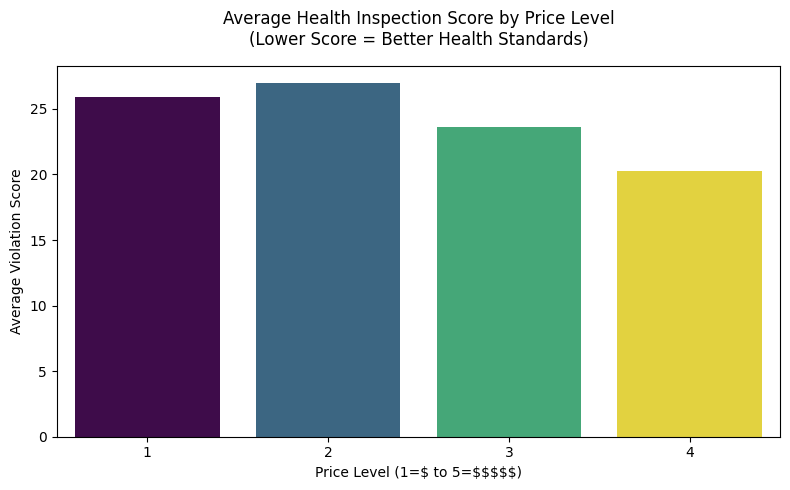

,price_level,num_restaurants,avg_health_score
0,1,1104,25.944001
1,2,1682,26.954402
2,3,90,23.643505
3,4,35,20.296296


In [36]:
# SQL Query: Average Inspection Score by Price Level
query_price = """
    SELECT 
        r.price_level, 
        COUNT(DISTINCT r.name) AS num_restaurants,
        AVG(i.SCORE) AS avg_health_score
    FROM ratings r
    JOIN inspections i 
        ON r.name = i.DBA 
        AND r.zip_code = i.ZIPCODE
    WHERE r.price_level IS NOT NULL 
        AND i.SCORE IS NOT NULL
    GROUP BY r.price_level
    ORDER BY r.price_level;
"""

price_analysis_df = pd.read_sql_query(query_price, conn)

# Visualization
plt.figure(figsize=(8, 5))

sns.barplot(
    data=price_analysis_df, 
    x="price_level", 
    y="avg_health_score", 
    hue="price_level", 
    palette="viridis", 
    legend=False
)

plt.title("Average Health Inspection Score by Price Level\n(Lower Score = Better Health Standards)", pad=15)
plt.xlabel("Price Level (1=\$ to 5=\$\$\$\$\$)") 
plt.ylabel("Average Violation Score")
plt.tight_layout()
plt.show()

price_analysis_df


### 5.2 Geospatial Analysis: Health Scores by ZIP Code
Leveraging `GeoPandas` to map the average health inspection scores across New York City neighborhoods. This spatial visualization helps identify high-risk zones and geographic patterns in restaurant compliance.

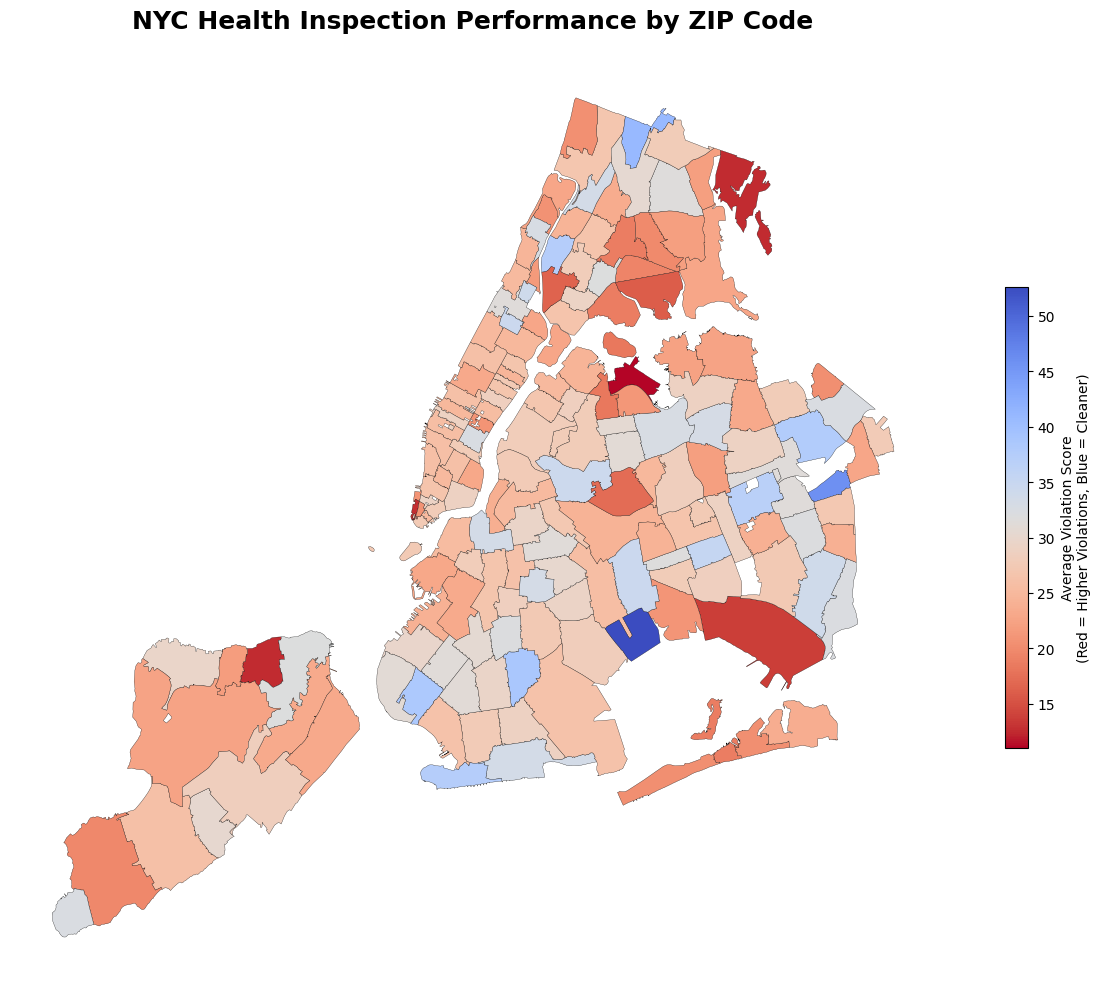

In [38]:
# 1. SQL Query: Aggregate scores by ZIP Code
query_map = """
    SELECT 
        ZIPCODE as zip_code, 
        AVG(SCORE) as avg_score,
        COUNT(DISTINCT DBA) as num_restaurants
    FROM inspections
    WHERE ZIPCODE IS NOT NULL AND SCORE IS NOT NULL
    GROUP BY ZIPCODE
    HAVING num_restaurants > 5; -- Filter out zip codes with too few restaurants
"""
zip_scores_df = pd.read_sql_query(query_map, conn)

# 2. Load the NY Zip Codes Shapefile using GeoPandas
shapefile_path = SPATIAL_DIR / "NY-zipcodes.shp"
nyc_map = gpd.read_file(shapefile_path)

# 3. Clean and prepare the spatial dataframe for merging
nyc_map.rename(columns={"ZCTA5CE20": "zip_code"}, inplace=True)
nyc_map["zip_code"] = pd.to_numeric(nyc_map["zip_code"], errors='coerce')

# 4. Merge Spatial Data with our SQL Data
merged_map = nyc_map.merge(zip_scores_df, on="zip_code", how="inner")

# 5. Plot the Choropleth Map
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# 'coolwarm_r': Red = Bad (High Violations), Blue = Good (Low Violations)
merged_map.plot(
    column="avg_score", 
    cmap="coolwarm_r", 
    legend=True,
    legend_kwds={"label": "Average Violation Score\n(Red = Higher Violations, Blue = Cleaner)", "shrink": 0.5},
    ax=ax, 
    edgecolor="black", 
    linewidth=0.2
)

ax.set_title("NYC Health Inspection Performance by ZIP Code", fontsize=18, fontweight="bold", pad=20)
ax.axis("off") 
plt.tight_layout()
plt.show()

### 5.3 Business Question 2: Which Cuisines are the Riskiest?
Analyzing health inspection scores across different cuisine types. We filter for cuisines with over 100 inspections to ensure statistical significance, identifying which types of food establishments struggle most with health compliance.

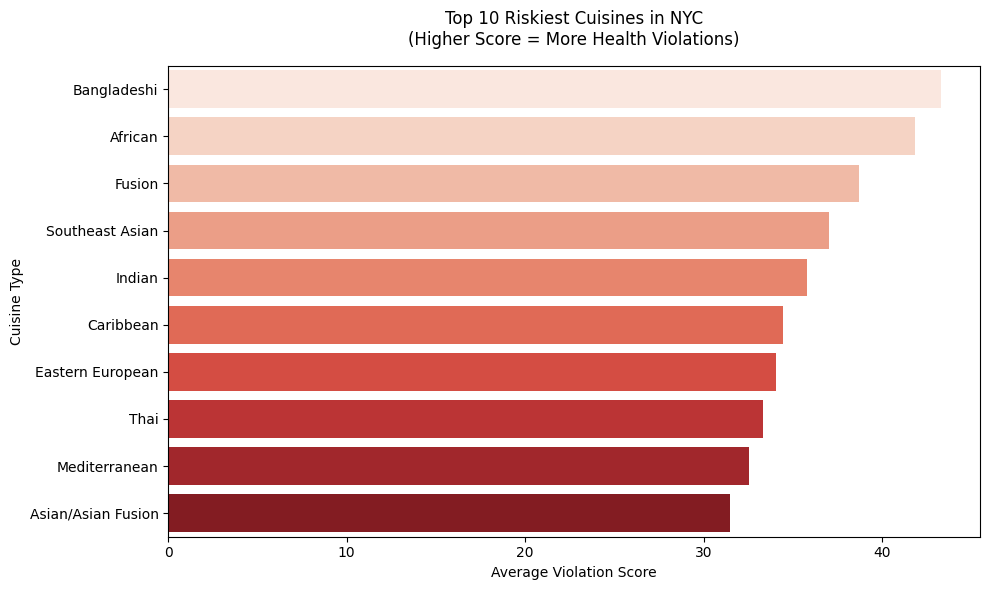

,cuisine,total_inspections,avg_score
0,Bangladeshi,233,43.321888
1,African,261,41.865900
2,Fusion,172,38.709302
3,Southeast Asian,187,37.053476
4,Indian,821,35.796590
5,Caribbean,1770,34.453107
6,Eastern European,217,34.064516
7,Thai,842,33.311164
8,Mediterranean,676,32.525148
9,Asian/Asian Fusion,1061,31.481621


In [41]:
query_cuisine = """
    SELECT 
        CUISINE_DESCRIPTION as cuisine,
        COUNT(CAMIS) as total_inspections,
        AVG(SCORE) as avg_score
    FROM inspections
    WHERE SCORE IS NOT NULL AND CUISINE_DESCRIPTION IS NOT NULL
    GROUP BY CUISINE_DESCRIPTION
    HAVING total_inspections > 100 -- Focus only on common cuisines
    ORDER BY avg_score DESC
    LIMIT 10;
"""

cuisine_df = pd.read_sql_query(query_cuisine, conn)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=cuisine_df, 
    x="avg_score", 
    y="cuisine", 
    hue="cuisine", 
    palette="Reds", 
    legend=False
)

plt.title("Top 10 Riskiest Cuisines in NYC\n(Higher Score = More Health Violations)", pad=15)
plt.xlabel("Average Violation Score")
plt.ylabel("Cuisine Type")
plt.tight_layout()
plt.show()

cuisine_df


### 5.4 Advanced Geospatial Analysis: Pinpointing the Riskiest Cuisine
As a Spatial Data Engineer, standard charts are not enough. We will dynamically identify the riskiest cuisine type, extract the precise coordinates (`Latitude`, `Longitude`) of those restaurants, and project them onto the NYC basemap using `GeoPandas` to identify specific clusters of health hazards.

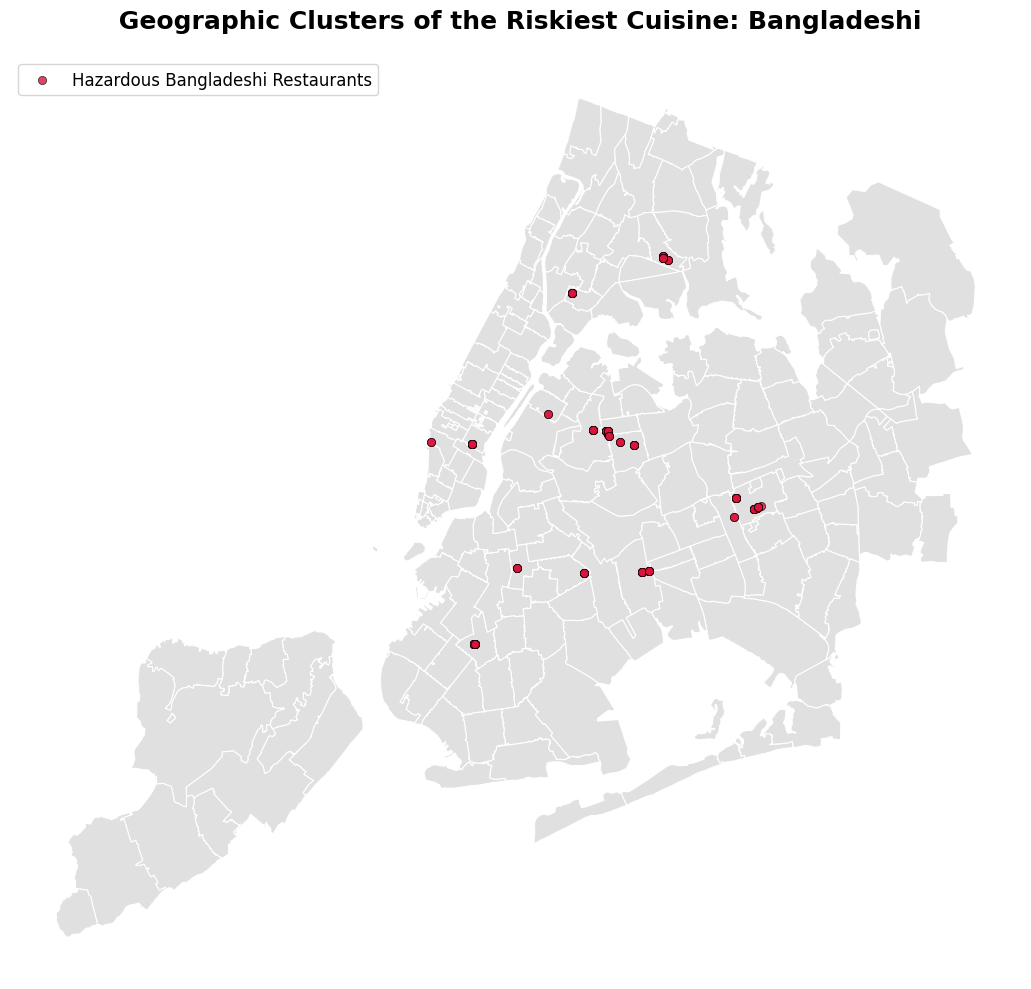

In [45]:
conn = sqlite3.connect(DB_PATH)

query_spatial_cuisine = """
    SELECT DBA, SCORE, Latitude, Longitude, CUISINE_DESCRIPTION as cuisine
    FROM inspections
    WHERE Latitude IS NOT NULL AND Longitude IS NOT NULL
    AND CUISINE_DESCRIPTION = (
        -- Subquery to dynamically find the #1 riskiest cuisine
        SELECT CUISINE_DESCRIPTION
        FROM inspections
        WHERE SCORE IS NOT NULL AND CUISINE_DESCRIPTION IS NOT NULL
        GROUP BY CUISINE_DESCRIPTION
        HAVING COUNT(CAMIS) > 100
        ORDER BY AVG(SCORE) DESC
        LIMIT 1
    );
"""
points_df = pd.read_sql_query(query_spatial_cuisine, conn)

conn.close()

worst_cuisine_name = points_df['cuisine'].iloc[0] if not points_df.empty else "Unknown"

gdf_points = gpd.GeoDataFrame(
    points_df, 
    geometry=gpd.points_from_xy(points_df.Longitude, points_df.Latitude),
    crs="EPSG:4326" 
)

fig, ax = plt.subplots(1, 1, figsize=(14, 10))

nyc_map.to_crs("EPSG:4326").plot(ax=ax, color='#e0e0e0', edgecolor='white', linewidth=0.8)

gdf_points.plot(
    ax=ax, 
    color='crimson', 
    markersize=35, 
    alpha=0.8, 
    edgecolor='black',
    linewidth=0.5,
    label=f'Hazardous {worst_cuisine_name} Restaurants'
)

ax.set_title(f" Geographic Clusters of the Riskiest Cuisine: {worst_cuisine_name}", fontsize=18, fontweight="bold", pad=20)
ax.axis("off")
plt.legend(fontsize=12, loc='upper left')
plt.tight_layout()
plt.show()

---
<div align="center">

  ###  Pipeline Architected & Developed by **[Abdelrahman Diaa]**
  **Data Analyst | Spatial Data Engineer**
  
  *Bridging the gap between raw data and business strategy through spatial intelligence.*
  
  [![LinkedIn](https://img.shields.io/badge/LinkedIn-Connect-blue?style=for-the-badge&logo=linkedin)](https://www.linkedin.com/in/diaa-shousha/)
  [![GitHub](https://img.shields.io/badge/GitHub-Explore_More_Projects-black?style=for-the-badge&logo=github)](https://github.com/bdiaa248)
  
</div>

---